# Electronic structure unfolding in supercells
Building a supercell (e.g. to host a defect or a moire pattern) folds the primitive-cell bands
into a smaller Brillouin zone. `get_supercell(n,store_primal=True)` keeps track of the original
primitive cell, so `get_kdos_bands(operator="unfold",...)` can unfold the supercell spectrum back
onto the primitive-cell k-path, weighting each supercell state by its overlap with the primitive
Bloch states.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

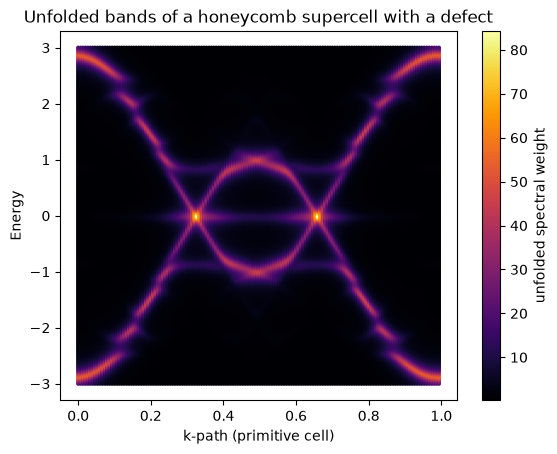

In [2]:
g0 = geometry.honeycomb_lattice()
n = 3
g = g0.get_supercell(n,store_primal=True)
h = g.get_hamiltonian()

fons = lambda r: (np.sum((r - g.r[0])**2)<1e-2)*100 # a strong onsite defect
h.add_onsite(fons)

kpath = np.array(g.get_kpath(nk=150))*n # k-path enlarged to the supercell BZ
(k,e,d) = h.get_kdos_bands(operator="unfold",delta=1e-1,kpath=kpath)

plt.scatter(k,e,c=d,cmap="inferno",s=4)
plt.colorbar(label="unfolded spectral weight")
plt.xlabel("k-path (primitive cell)") ; plt.ylabel("Energy")
plt.title("Unfolded bands of a honeycomb supercell with a defect")
plt.show()